In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# 1. Generate a mixed 3D Gaussian cloud
np.random.seed(42)

mean1 = np.array([0, 0, 0])
#mean2 = np.array([5, 5, 5])

# Create a covariance matrix where variance is mostly in 2 directions, not aligned with cartesian axes
# Eigenvalues: two large, one small for the 'narrow' aspect
evals = np.array([24.49, 0.5, 0.01]) # Variances along principal axes

# Create a random rotation matrix for the eigenvectors
def random_rotation_matrix():
    q = np.random.rand(4)
    q = q / np.linalg.norm(q)
    return np.array([
        [1 - 2*q[2]**2 - 2*q[3]**2, 2*q[1]*q[2] - 2*q[0]*q[3], 2*q[1]*q[3] + 2*q[0]*q[2]],
        [2*q[1]*q[2] + 2*q[0]*q[3], 1 - 2*q[1]**2 - 2*q[3]**2, 2*q[2]*q[3] - 2*q[0]*q[1]],
        [2*q[1]*q[3] - 2*q[0]*q[2], 2*q[2]*q[3] + 2*q[0]*q[1], 1 - 2*q[1]**2 - 2*q[2]**2]
    ])

rotation_matrix = random_rotation_matrix()

# Construct covariance matrix: R * diag(evals) * R^T
# This ensures the principal axes are rotated.
cov1 = rotation_matrix @ np.diag(evals) @ rotation_matrix.T

# Generate samples
num_samples = 500
X = np.random.multivariate_normal(mean1, cov1, num_samples)

# 2. Perform PCA
pca = PCA(n_components=3) # Initially fit for 3 components to analyze variance
pca.fit(X)

# Print explained variance ratio
print(f"Explained variance ratio (3 components): {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance (3 components): {np.cumsum(pca.explained_variance_ratio_)}")

# Project data along the leading 2 principal components
pca_2d = PCA(n_components=2)
X_projected = pca_2d.fit_transform(X)

print(X.shape)

Explained variance ratio (3 components): [9.78501127e-01 2.11484640e-02 3.50408736e-04]
Cumulative explained variance (3 components): [0.97850113 0.99964959 1.        ]
(500, 3)


In [ ]:
import numpy as np

# Show equivalence of Singular Value Decomposition to PCA
[U,sigma,Vt] = np.linalg.svd(X)
print(f"Explained variance ratio (3 components): {sigma**2/np.sum(sigma**2)}")
print(f"Cumulative explained variance (3 components): {np.cumsum(sigma**2/np.sum(sigma**2))}")


Xr = X.dot(Vt[:3,:].T)
Xr.shape

Explained variance ratio (3 components): [9.78446491e-01 2.11983157e-02 3.55193007e-04]
Cumulative explained variance (3 components): [0.97844649 0.99964481 1.        ]


(500, 3)

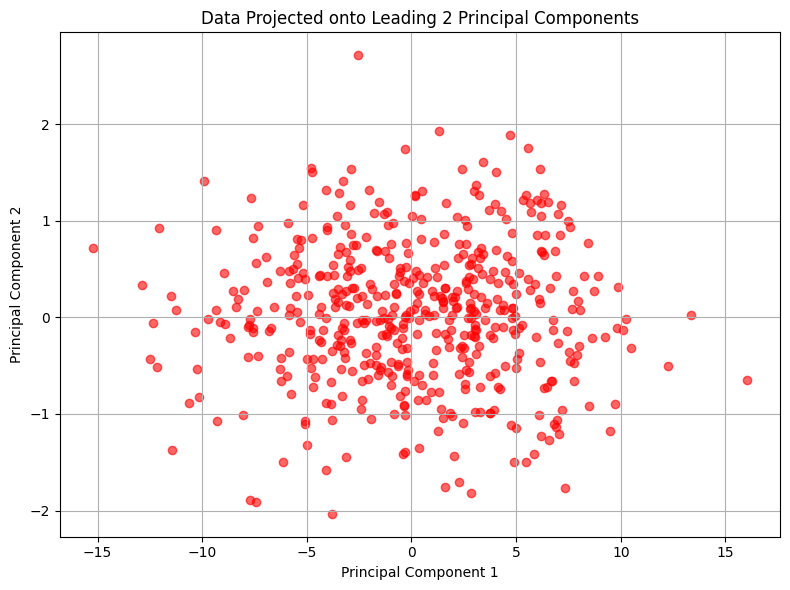

In [ ]:
import plotly.graph_objects as go

# 3. Visualize original 3D data interactively with Plotly
fig_3d = go.Figure(data=[go.Scatter3d(
    x=X[:, 0],
    y=X[:, 1],
    z=X[:, 2],
    mode='markers',
    marker=dict(size=5,color='blue',opacity=0.6)
)])

fig_3d.update_layout(
    title='Original 3D Gaussian Cloud (Interactive)',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z'
    ),
    height=800
)
fig_3d.show()

# 4. Visualize projected data along the leading 2 principal components (static Matplotlib)
plt.figure(figsize=(8, 6))
plt.scatter(Xr[:, 0], Xr[:, 1], c='red', marker='o', alpha=0.6)
plt.title('Data Projected onto Leading 2 Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

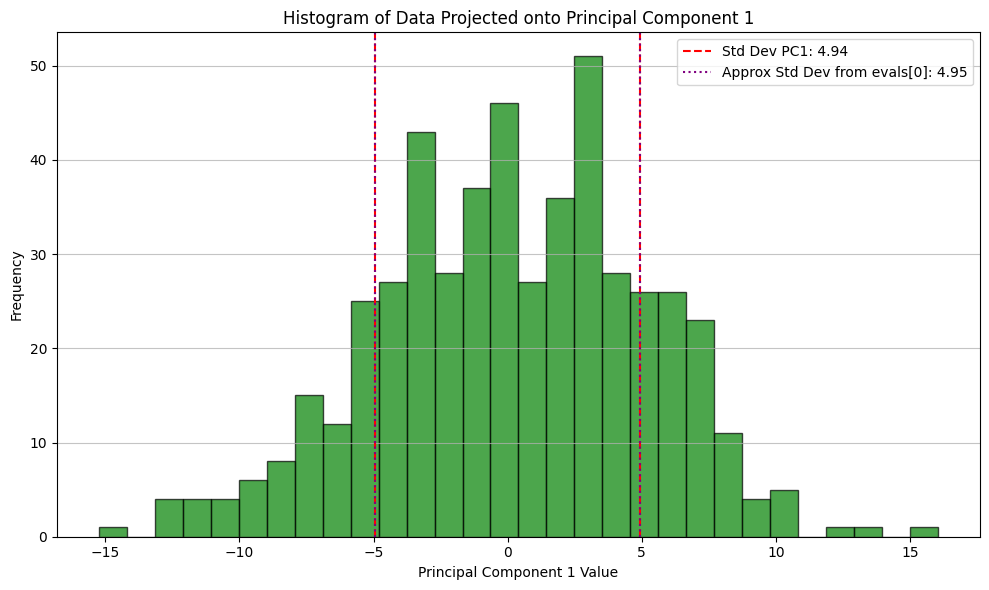

Standard deviation of data projected onto PC1: 4.9400
Approximate standard deviation from original 'evals[0]': 4.9487


In [ ]:
plt.figure(figsize=(10, 6))

# Data projected onto the first principal component
pc1_data = Xr[:, 0] # Using Xr which is derived from SVD and equivalent to PCA projection

# Plot histogram
plt.hist(pc1_data, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title('Histogram of Data Projected onto Principal Component 1')
plt.xlabel('Principal Component 1 Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Calculate standard deviation
std_pc1 = np.std(pc1_data)

# Approximate standard deviation from original 'evals' (square root of the largest eigenvalue)
# The 'evals' were used to construct the covariance matrix, so their square roots represent
# the standard deviations along the true principal axes of the generated data.
std_from_evals = np.sqrt(evals[0])

plt.axvline(x=std_pc1, color='red', linestyle='--', label=f'Std Dev PC1: {std_pc1:.2f}')
plt.axvline(x=-std_pc1, color='red', linestyle='--')
plt.axvline(x=std_from_evals, color='purple', linestyle=':', label=f'Approx Std Dev from evals[0]: {std_from_evals:.2f}')
plt.axvline(x=-std_from_evals, color='purple', linestyle=':')

plt.legend()
plt.tight_layout()
plt.show()

print(f"Standard deviation of data projected onto PC1: {std_pc1:.4f}")
print(f"Approximate standard deviation from original 'evals[0]': {std_from_evals:.4f}")